# FINANCIAL INTERMEDIATION AND DEFAULT

In [1]:
# PACKAGES
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

try:
    # Works if running as a .py script
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "Discretisation" / "Outputs"


In [2]:
# CALIBRATION
calibration_start = {

    #==> Household parameters (single deposit asset)
    'frisch': 1.0,
    'eis': 0.5,
    'habit': 0.00,
    'C_lag': 0.0,

    #==> Rates
    'rdep': 0.0065,
    'rb': 0.0065,

    #==> Government bonds
    'B_supply': 0.6*4,

    #==> Policy parameters
    'b_gov':    0.6*4,
    'b_gov_ss': 0.6*4,

    'tau': 0.181,
    'lamb': 0.85,
    'lamb_ss': 0.85,
    'phi_lamb': 0.05,

    'shock_def':     0.0,
    'def_rate':      0.0,
    'def_curvature': 0.5,
    'recovery_rate': 0.40,

    ##==> Aggregate targets
    'Y':  1.00,
    'N':  1.00,
    'w':  0.70,

    ##==> Financial intermediary
    'lambda_gk': 0.2057999,   # recalibrated: alpha_b/(theta+phi_b) ≈ 0.985/4.8
    'ksi':       0.5,
    'n_inter':   0.75*4,
    'theta':     4,
    'psi': 0.94,           # banker survival probability
    'mu':  0.0,            # leverage constraint multiplier (0 in SS)

    #==> Production
    'alpha': 0.35,
    'delta': 0.0125,

    #==> Deposit grid
    'nZ':    19,
    'nDep':  500,
    'Depmax': 150,

    #==> Not used unless nZ != 19
    'rho_z':   0.9,
    'sigma_z': 0.5,

    #==> Tobin's q
    'Q': 1.0,

    #==> Wage and Price Rigidity
    'pi_w':      0.0,
    'pi':        0.0,
    'epsilon_w': 6.0,
    'theta_w':   100.0,
}

calibration_hh = {
    **calibration_start,
    'beta': 0.9927516024910438,
    'div':  0.188490,
}


In [3]:
# INITIAL GUESS, HH, GRRIDS, INCOME
def hh_init(dep_grid, z, rdep, eis):
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    Vdep = (1 + rdep) * coh ** (-1 / eis)
    return Vdep

# 2. Backward Step (HH Block)
@sj.het(exogenous='Pi', policy='dep', backward='Vdep', backward_init=hh_init)
def hh(Vdep_p, dep_grid, z, t_paid, rdep, beta, eis):
    uc_nextgrid = beta * Vdep_p
    c_nextgrid = uc_nextgrid ** (-eis)
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    
    dep = sj.interpolate.interpolate_y(c_nextgrid + dep_grid, coh, dep_grid)
    sj.misc.setmin(dep, dep_grid[0])
    
    c = coh - dep
    uce = c ** (-1 / eis)        
    Vdep = (1 + rdep) * uce
    
    # Broadcast individual tax paid to the full state-space grid
    # sequence_jacobian will automatically integrate this into aggregate 'TAX'
    tax = t_paid[:, np.newaxis] + np.zeros_like(dep_grid[np.newaxis, :])
    
    return Vdep, dep, c, uce, tax

# 3. Grids and Income
def make_grids(Depmax, nDep, nZ, rho_z, sigma_z):
    dep_grid = grids.agrid(amax=Depmax, n=nDep)

    if nZ == 19:
        e_grid = np.loadtxt(DATA_DIR / "x_vec.txt").flatten()
        Pi = np.loadtxt(DATA_DIR / "Px_GMAR.txt")
        Pi = Pi / Pi.sum(axis=1, keepdims=True)
        Pi[:, -1] = 1.0 - Pi[:, :-1].sum(axis=1)
    else:
        e_grid, _, Pi = grids.markov_rouwenhorst(rho=rho_z, sigma=sigma_z, N=nZ)

    return e_grid, Pi, dep_grid


def income(e_grid, w, N, div, tau, lamb):
    # Endogenous labor: wages are multiplied by hours worked (N)
    y_pre = w * N * e_grid + div
    z = lamb * (y_pre ** (1 - tau))
    t_paid = y_pre - z
    return z, t_paid

hh_extended = hh.add_hetinputs([make_grids, income])

### EQUATIONS

#### STEADY STATE EQUATIONS

In [4]:
@simple
def smart_steady(theta, Y, n_inter, rdep, alpha, delta, psi, N, B_supply, rb):
    K        = theta * n_inter
    phi_b    = B_supply / n_inter
    rk       = alpha * Y / K - delta
    rn       = theta * (rk - rdep) + phi_b * (rb - rdep) + rdep
    m        = n_inter * (1 - psi * (1 + rn))
    k_inter  = K
    I        = K * delta
    D_supply = (theta - 1) * n_inter + B_supply
    Z        = Y / ((K ** alpha) * (N ** (1 - alpha)))
    rdep_ante = rdep
    return K, rk, rn, m, k_inter, I, D_supply, Z, rdep_ante, phi_b

@simple
def market_clearing(Y, C, I, G, DEP, D_supply):
    goods_mkt = Y - C - I - G 
    deposit_mkt = DEP - D_supply
    return goods_mkt, deposit_mkt

@simple
def steady_auxilliary(theta, rk, rdep, rb, delta, alpha, Y, K, N, lambda_gk, beta, ksi, rn, phi_b):
    iota   = delta
    mpk    = alpha * (Y / K)
    w      = (1 - alpha) * Y / N
    Omega  = theta * lambda_gk / (beta * ((1 + rn) - phi_b * (rb - rdep)))
    nu     = beta * Omega * (rk - rdep)
    eta    = beta * Omega * (1 + rdep)
    gamma0 = delta ** ksi / (1 - ksi)
    gamma1 = -delta * ksi / (1 - ksi)
    return iota, mpk, w, Omega, nu, eta, gamma0, gamma1

@simple
def banker_div(psi, rn, n_inter):
    # Only exiting bankers  pay dividends
    div = (1 - psi) * (1 + rn) * n_inter
    return div

@simple
def bocola_ss(beta, rdep, psi , theta, phi_b):
    # Bocola Eq. 5 evaluated at SS (mu=0): solve alpha_b = Lambda_hat*(1+rdep)
    # Lambda_hat = beta*((1-psi) + psi*alpha_b)  =>  closed-form solution
    alpha_b = beta * (1 + rdep) * (1 - psi) / (1 - beta * (1 + rdep) * psi)
    lambda_gk = alpha_b / (theta + phi_b)
    return alpha_b, lambda_gk

@simple
def sdf(beta, UCE):
    SDF = beta * UCE(+1) / UCE
    return SDF

@simple
def government_ss(TAX, rb, B_supply):
    # Government expenditure is constant
    G = TAX - rb * B_supply
    return G

@simple
def labor_ss(w, N, UCE, frisch):
    vphi = w * UCE / (N ** (1 / frisch))
    return vphi


#### OFF STEADY-STATE EQUATIONS


In [5]:
# OFF-STEADY-STATE EQUATIONS

# ==> CAPITAL BLOCK
@simple
def capital_adj(Y, K, Q, I, alpha, delta, gamma0, gamma1, ksi, Z):
    iota        = I / K(-1)
    mpk         = alpha * Y*Z / K(-1)
    rk          = (mpk + (1 - delta) * Q) / Q(-1) - 1
    q_res       = Q - 1 / (gamma0 * (1 - ksi) * iota ** (-ksi))
    capital_res = K - (1 - delta) * K(-1) - (gamma0 * iota ** (1 - ksi) + gamma1) * K(-1)
    return iota, mpk, rk, q_res, capital_res

@simple
def rk_from_production(Y, K, alpha, delta):
    rk = alpha * Y / K(-1) - delta
    return rk


# ==> LABOUR MARKET BLOCK
@simple
def labor(Y, Z, K, alpha):
    N = (Y / (Z * K(-1) ** alpha)) ** (1 / (1 - alpha))
    w = (1 - alpha) * Y / N
    return N, w

@simple
def labor_market(w, UCE, N, vphi, frisch):
    mrs = vphi * N**(1/frisch) / UCE
    labor_mkt_res = w - mrs
    return labor_mkt_res


# ==> FINANCIAL INTERMEDIATION BLOCK

@simple
def banker_sdf(SDF, psi, alpha_b, mu, rdep, lambda_gk):
    # Bocola Eq. 9: banker's augmented SDF
    Lambda_hat = SDF * ((1 - psi) + psi * alpha_b(+1))
    # Bocola Eq. 5: marginal value of wealth residual
    alpha_b_res = alpha_b - Lambda_hat * (1 + rdep(+1)) / (1 - mu)
    return Lambda_hat, alpha_b_res

@simple
def bank_return(theta, rk, rdep, b_gov, n_inter, rb, def_rate):
    # Realized ex-post bond return (Bocola: haircut applies on default)
    phi_b_lag = b_gov(-1) / n_inter(-1)
    rb_actual  = (1 - def_rate) * (1 + rb(-1)) - 1
    rn = theta(-1) * (rk - rdep) + phi_b_lag * (rb_actual - rdep) + rdep
    return rn, rb_actual

@simple
def bank_pricing(rb_actual, rdep, mu, lambda_gk, Lambda_hat_ss):
    euler_bonds = Lambda_hat_ss * (rb_actual(+1) - rdep(+1)) - lambda_gk * mu
    return euler_bonds

@simple
def bank_balance_sheet(psi, rn, n_inter, m, div):
    # Bocola net worth accumulation: only surviving bankers (psi) retain earnings
    earnings    = (1 + rn) * n_inter(-1)
    n_inter_val = psi * earnings + m - n_inter   # target: = 0
    # Exiting bankers (1-psi) pay earnings as dividends to households
    div_res     = div - (1 - psi) * earnings     # target: = 0
    return n_inter_val, div_res

@simple
def theta_from_leverage(alpha_b, lambda_gk, b_gov, n_inter):
    # Bocola leverage constraint: K + B = (alpha_b/lambda_gk) * n_inter
    # => theta = alpha_b/lambda_gk - phi_b  (replaces GK IC constraint)
    phi_b = b_gov / n_inter
    theta = alpha_b / lambda_gk - phi_b
    return theta

@simple
def intermediation_P3(theta, n_inter, b_gov):
    D_supply = (theta - 1) * n_inter + b_gov
    return D_supply

@simple
def k_balance_sheet(theta, n_inter, K):
    K_res = K - theta * n_inter
    return K_res


# ==> GOVERNMENT AND MONETARY POLICY BLOCK

@simple
def interest_rates(def_rate, recovery_rate, rdep):
    #CHECK
    rb = (1+rdep) / (1 - def_rate(+1) * (1.0 - recovery_rate))-1
    return rb

@simple
def tax_rule(b_gov, lamb_ss, b_gov_ss, phi_lamb):
    lamb = lamb_ss + phi_lamb * (b_gov(-1) - b_gov_ss)
    return lamb


@simple
def government_default(shock_def):
    #Simplest exogenous shock (always positive)
    def_rate = shock_def
    return def_rate


@simple
def budget_residual(b_gov, G, TAX, rb, def_rate, recovery_rate):
    haircut = 1.0 - recovery_rate
    effective_repayment = (1 - def_rate * haircut) * (1 + rb(-1)) * b_gov(-1)
    b_gov_res = effective_repayment + G - TAX - b_gov
    return b_gov_res


### SOLVING MODEL

#### STEADY STATE

In [6]:
# CALCULATE STEADY STATE
ha = sj.create_model([
    hh_extended,
    smart_steady,
    government_ss,
    market_clearing,
    steady_auxilliary,
    banker_div,
    bocola_ss,         
    labor_ss,
    sdf
], name="STEADY STATE Model")

unknowns_ss = {'beta': (0.99, 0.993)}
targets_ss  = ['deposit_mkt']

solver_options = {
    'hh': {
        'forward_maxit': 200000,
        'forward_tol': 1e-10
    }
}

ss = ha.solve_steady_state(
    calibration_start,
    unknowns_ss,
    targets_ss,
    solver='bisect',
    options=solver_options
)

print(f"beta      = {ss['beta']:.8f}")
print(f"alpha_b   = {ss['alpha_b']:.6f}")
print(f"div       = {ss['div']:.6f}")

cali = ss
calibration = dict(ss)


beta      = 0.99280868
alpha_b   = 0.987840
div       = 0.188490


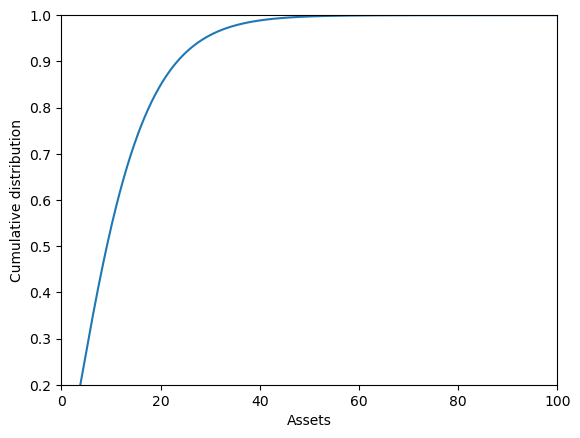

In [7]:
# GRAPH OF THE ASSET DISTRIBUTION
D = ss.internals['hh']['D'].sum(axis=0)
dep_grid = ss.internals['hh']['dep_grid']
plt.plot(dep_grid, D.cumsum())
plt.ylim([0.2, 1])
plt.xlim([0, 100])
plt.xlabel('Assets')
plt.ylabel('Cumulative distribution')
plt.show()

#### FULL MODEL

In [8]:
print("Bocola framework: theta determined by leverage constraint — no inner financial solver.")
print("alpha_b and mu are outer unknowns (targets: alpha_b_res, euler_bonds).")

# Verify SS consistency: alpha_b/lambda_gk should equal theta + phi_b
alpha_b_ss  = float(cali['alpha_b'])
lambda_gk   = float(cali['lambda_gk'])
theta_ss    = float(cali['theta'])
phi_b_ss    = float(cali['B_supply']) / float(cali['n_inter'])
implied_lev = alpha_b_ss / lambda_gk
target_lev  = theta_ss + phi_b_ss


# 1. Force exact SS consistency for lambda_gk to fix leverage constraints
target_lev = calibration['theta'] + calibration['b_gov'] / calibration['n_inter']
calibration['lambda_gk'] = calibration['alpha_b'] / target_lev

# 2. Re-align 'm' so the bank_balance_sheet target evaluates to EXACTLY 0
calibration['m'] = calibration['n_inter'] * (1 - calibration['psi'] * (1 + calibration['rn']))

print(f"\nalpha_b / lambda_gk  = {implied_lev:.8f}")
print(f"theta + phi_b (target) = {target_lev:.8f}")
print(f"Recalibrate lambda_gk to {alpha_b_ss / target_lev:.8f} for exact SS consistency.")


Bocola framework: theta determined by leverage constraint — no inner financial solver.
alpha_b and mu are outer unknowns (targets: alpha_b_res, euler_bonds).

alpha_b / lambda_gk  = 4.80000000
theta + phi_b (target) = 4.80000000
Recalibrate lambda_gk to 0.20579992 for exact SS consistency.


In [9]:
# HA FULL MODEL (Bocola financial sector)
ha_full = sj.create_model([
    hh_extended,
    theta_from_leverage,   
    banker_sdf,            
    bank_return,           
    bank_pricing,          
    bank_balance_sheet,    
    intermediation_P3,     
    k_balance_sheet,       
    capital_adj,
    sdf,
    interest_rates,
    government_default,
    tax_rule,
    budget_residual,
    labor,
    labor_market,          
    market_clearing
], name="Full HANK Model — Bocola")

calibration = ss.copy()

target_lev = calibration['theta'] + calibration['b_gov'] / calibration['n_inter']
calibration['lambda_gk'] = calibration['alpha_b'] / target_lev
calibration['m'] = calibration['n_inter'] * (1 - calibration['psi'] * (1 + calibration['rn']))

calibration.update(ha_full.steady_state(calibration))

# Exactly 10 unknowns
unknowns_tp = ['rdep', 'K', 'n_inter', 'div', 'I', 'Q', 'b_gov', 'Y', 'alpha_b', 'mu']

# Exactly 10 targets matching the unknowns
targets_tp = [
    'deposit_mkt', 'K_res', 'n_inter_val', 'div_res',
    'capital_res', 'q_res', 'b_gov_res', 'labor_mkt_res',
    'alpha_b_res', 'euler_bonds'
]
T = 300
exogenous = ['Z']

G = ha_full.solve_jacobian(calibration, unknowns_tp, targets_tp, exogenous, T=T)

KeyError: 'Lambda_hat_ss'

In [ ]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=40, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            ax[i].plot(irf[variables[i]][:T_plot], label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

Computing linear impulse responses (TFP shock)...


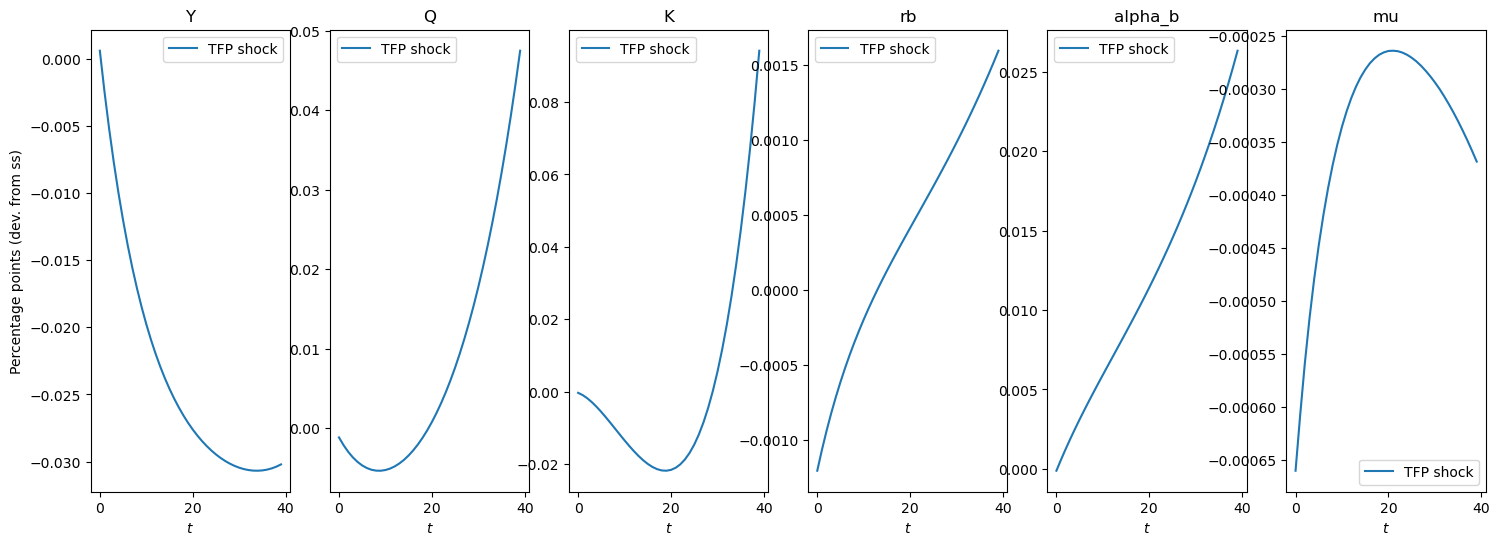

In [ ]:
# Impulse Response Functions — TFP Shock
rho_Z = 0.9
dZ    = 0.01 * rho_Z ** np.arange(T)
shocks = {'Z': dZ}

print("Computing linear impulse responses (TFP shock)...")
irfs = ha_full.solve_impulse_linear(calibration, unknowns_tp, targets_tp, shocks)

show_irfs([irfs], ['Y', 'Q', 'K','rb', 'alpha_b', 'mu'],
          labels=['TFP shock'])


Computing linear impulse responses (default shock)...


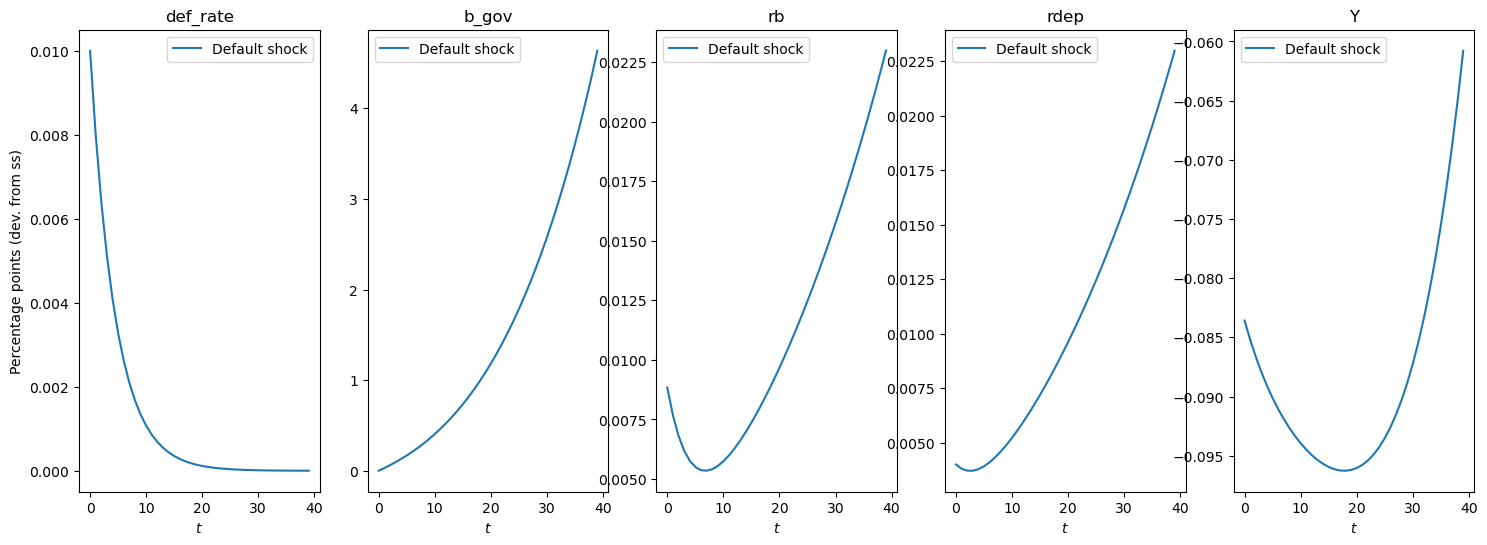

In [ ]:
# Impulse Response Functions — Default Shock
rho_def    = 0.8
dShock_def = 0.01 * rho_def ** np.arange(T)
shocks = {'shock_def': dShock_def}

print("Computing linear impulse responses (default shock)...")
irfs_def = ha_full.solve_impulse_linear(calibration, unknowns_tp, targets_tp, shocks)

show_irfs([irfs_def], ['def_rate', 'b_gov', 'rb', 'rdep', 'Y'],
          labels=['Default shock'])
